In [163]:
%cd "data"


[Errno 2] No such file or directory: 'data'
/Users/khb43/Desktop/HANKYUNG_WITH_TOSS_BANK-2(소민호 강사님)/week15/data


In [164]:
!unzip -n "idol_face_datasets.zip"

Archive:  idol_face_datasets.zip


In [165]:
TRAIN_MATADATA_PATH = '../data/kid_f_train.csv'
TEST_METADATA_PATH = '../data/kid_f_test.csv'

In [166]:
TRAIN_IMAGE_DIR = "../data/HQ_512x512/HQ_512x512"
TEST_IMAGE_DIR = "../data/test_final_with_degrad/test"

# 데이터 로딩 및 메타데이터 세트 구축

In [167]:
import pandas as pd

df_train = pd.read_csv(TRAIN_MATADATA_PATH)
df_test = pd.read_csv(TEST_METADATA_PATH)


In [168]:
df_train

,file_name,name
0,5.jpg,yujin
1,8.jpg,yujin
2,17.jpg,yujin
3,23.jpg,yujin
4,26.jpg,yujin
...,...,...
5586,85499.jpg,jisoo
5587,85500.jpg,jisoo
5588,85508.jpg,jisoo
5589,85518.jpg,jisoo


In [169]:
df_test

,file_name,name
0,45.jpg,yujin
1,67.jpg,iu
2,85.jpg,winter
3,96.jpg,winter
4,112.jpg,winter
...,...,...
295,85363.jpg,jisoo
296,85387.jpg,jisoo
297,85451.jpg,jisoo
298,85458.jpg,jisoo


In [170]:
df_train['name'].value_counts()

name
lisa                  1282
rose                  1245
jisoo                 1023
jennie                 414
kimminju               261
joyuri                 257
choiyena               135
hondahitomi            119
kimchaewon             119
kanghyewon              83
sakura                  79
nayeon                  76
oliviahye               72
kwoneunbi               70
yujin                   55
wonyoung                50
hongeunchae             35
ningning                28
karina                  25
giselle                 23
huhyunjin               22
winter                  21
kazuha                  18
bravegirls_yuna         16
minyoung                11
bravegirls_yujeong       6
hani                     6
bravegirls_eunji         6
jihyo                    3
momo                     2
hyerin                   2
chaewon                  2
seeun                    2
hyuna                    2
dasom                    1
hwasa                    1
sana                   

In [171]:
# name의 value_counts()가 400개 이상인 데이터만 사용
df_train = df_train[df_train['name'].isin(df_train['name'].value_counts()[df_train['name'].value_counts() >= 400].index)]
df_train['name'].value_counts()

name
lisa      1282
rose      1245
jisoo     1023
jennie     414
Name: count, dtype: int64

In [172]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3964 entries, 1481 to 5590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  3964 non-null   object
 1   name       3964 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


In [173]:
# name을 이용해 Label Encoding
df_train['target'] = df_train['name'].astype('category').cat.codes
df_train

/var/folders/zk/p59k4t_16mlgf68b5hxclv6m0000gn/T/ipykernel_66384/3180055230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['target'] = df_train['name'].astype('category').cat.codes


,file_name,name,target
1481,7085.jpg,jisoo,1
1482,7091.jpg,jisoo,1
1483,7104.jpg,jisoo,1
1484,7107.jpg,jisoo,1
1485,7122.jpg,jisoo,1
...,...,...,...
5586,85499.jpg,jisoo,1
5587,85500.jpg,jisoo,1
5588,85508.jpg,jisoo,1
5589,85518.jpg,jisoo,1


In [174]:
# name_to_target
name_to_target = dict(zip(df_train['name'], df_train['target']))
name_to_target

{'jisoo': 1, 'jennie': 0, 'rose': 3, 'lisa': 2}

In [175]:
# target_to_name
target_to_name = dict(zip(df_train['target'], df_train['name']))
target_to_name

{1: 'jisoo', 0: 'jennie', 3: 'rose', 2: 'lisa'}

# 파이토치 데이터 로더 구성

In [176]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_train,
    test_size= 0.2,
    random_state=42,
    stratify = df_train['target']
)

In [177]:
# Pandas 데이터 프레임 기반 파이토치 데이터 세트

import torch
import os
from PIL import Image
from torch.utils.data import Dataset

class IdolDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):
        super().__init__()

        self.dataframe = dataframe
        self.img_dir = img_dir # 메타 데이터에 경로가 없기에 필요함
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Dataset 내에는 오른쪽과 같이 두개가 짝꿍으로 구성 X = file name | y = target
        # idx를 통해 데이터를 가져옴

        # 데이터 프레임에서 이미지 파일 경로, 레이블 추출

        img_name = os.path.join(self.img_dir, self.dataframe.iloc[idx, 0]) # 배열의 인덱스이므로 loc가 아닌 iloc를 사용   
        label = self.dataframe.iloc[idx, 2]

        # 이미지 로드 및 변환
        image = Image.open(img_name)

        if self.transform:
            image = self.transform(image)

        # 레이블을 텐서로 변환
        label = torch.tensor(label)
        
        return image, label


In [178]:
# 데이터 로더 구성
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), # R | G | B 에 대한 연구되어진 표준편차 값으로 정규화
                        (0.229, 0.224, 0.225))]
)


In [179]:
from torch.utils.data import DataLoader
# 데이터 세트 저으이

train_dataset = IdolDataset(dataframe=train_df, img_dir=TRAIN_IMAGE_DIR, transform=transform)
valid_dataset = IdolDataset(dataframe=val_df, img_dir=TRAIN_IMAGE_DIR, transform=transform)

# 데이터 로더 정의

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(valid_dataset, batch_size=32, shuffle=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

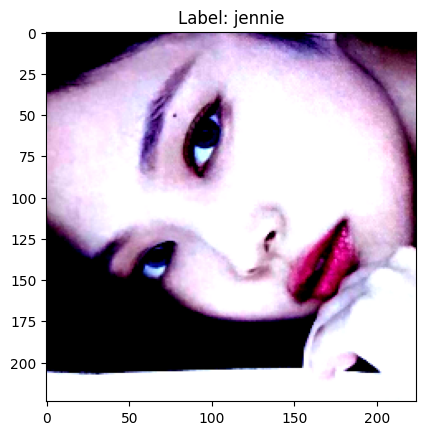

In [180]:
import matplotlib.pyplot as plt
import numpy as np

sample_batch = next(iter(train_loader))
for image, label in zip(*sample_batch):
    image = image.numpy().transpose((1, 2, 0))
    plt.title(f"Label: {target_to_name[label.item()]}")
    plt.imshow(image)

# 모델 훈련 준비

In [181]:
import torch

# MPS 지원 여부 확인
if torch.backends.mps.is_available():
    device = 'mps'  # MPS 사용
elif torch.cuda.is_available():
    device = 'cuda'  # CUDA 사용 가능 시
else:
    device = 'cpu'  # 그 외에는 CPU 사용

print(device)

mps


In [183]:
# 훈련 루프 정의
def train_loop(dataloader, model, loss_fn, optimizer):

    # 데이터 로더에 있는 데이터 세트의 길이 가져오기
    size = len(dataloader.dataset)
    model.train() # 모델을 훈련 모드로 설정
    for batch, (X, y) in enumerate(dataloader):

        # 데이터 로더에 들어있던 텐서들을 gpu로 옮기기
        X, y = X.to(device), y.to(device)

        # 예측 및 손실 확인
        pred = model(X)
        loss = loss_fn(pred, y)

        # 역전파 수행(미분)
        optimizer.zero_grad() # 기존에 남아있던 gradient 제거( 이전 배치의 기울기를 반영하지 않게 하기 위해)
        loss.backward() # 역전파
        optimizer.step()

        # 배치가 100번 돌 때마다 화면에 출력
        if batch % 10 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"Train Loss : {loss:>7f} [ {current:>5d} / {size:>5d} ]")

In [182]:
# 추론 루프 정의
def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)

    test_loss, correct = 0, 0
    model.eval() # 모델을 추론모드로 설정
    # 추론 과정은 기울기를 구하지 않음
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    num_batches = len(dataloader)

    # 배치 별 loss값의 평균 구하기
    test_loss /= num_batches
    correct /= size

    print(f"Test Error : \n Accuracy : {(100*correct):>0.1f}%, Avg Loss : {test_loss:>8f}\n")

# 모델 직접 정의

In [184]:
from torch import nn

class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
            )
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.Maxpool3 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(
        # 224/2/2/2 * 224/2/2/2 * 128
        nn.Linear(100352, 512),
        nn.ReLU(),
        nn.Linear(512, 4)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [185]:
model = CNN_deep().to(device)
print(model)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

In [186]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 학습 수행
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n........................")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(val_loader, model, loss_fn)

print("Done!")

Epoch 1
........................
Train Loss : 1.322012 [     0 /  3171 ]
Train Loss : 2.158880 [   320 /  3171 ]
Train Loss : 1.544611 [   640 /  3171 ]
Train Loss : 1.281939 [   960 /  3171 ]
Train Loss : 0.547355 [  1280 /  3171 ]
Train Loss : 1.074833 [  1600 /  3171 ]
Train Loss : 0.991665 [  1920 /  3171 ]
Train Loss : 0.795792 [  2240 /  3171 ]
Train Loss : 0.663361 [  2560 /  3171 ]
Train Loss : 0.499303 [  2880 /  3171 ]
Test Error : 
 Accuracy : 73.9%, Avg Loss : 0.659373

Epoch 2
........................
Train Loss : 0.421788 [     0 /  3171 ]
Train Loss : 0.601948 [   320 /  3171 ]
Train Loss : 0.426974 [   640 /  3171 ]
Train Loss : 0.356815 [   960 /  3171 ]
Train Loss : 0.364779 [  1280 /  3171 ]
Train Loss : 0.545417 [  1600 /  3171 ]
Train Loss : 0.646696 [  1920 /  3171 ]
Train Loss : 0.665973 [  2240 /  3171 ]
Train Loss : 0.634132 [  2560 /  3171 ]
Train Loss : 0.395337 [  2880 /  3171 ]
Test Error : 
 Accuracy : 82.3%, Avg Loss : 0.457923

Epoch 3
..................

# 전이학습

**이미 공부해본 애** 공부시키거나 시험보게 하기

**전이학습(Transfer Learning)**은 머신러닝과 딥러닝에서 미리 학습된 모델의 지식을 새로운 문제에 적용하는 기법을 말합니다. 

이는 기존에 학습된 모델이 다른 유사한 문제에서 얻은 지식을 새로운 작업에 전이(transfer)하는 개념입니다.

* 전이학습의 주요 개념:

1. 사전 학습된 모델(Pre-trained Model):

먼저, 큰 데이터셋(예: ImageNet 같은 수백만 장의 이미지 데이터셋)에서 모델을 학습시킵니다. 

이 학습 과정에서 모델은 이미지나 텍스트의 기본적인 패턴이나 특징을 학습합니다.

2. 미리 학습된 가중치 재사용:

새로운 문제를 해결할 때, 처음부터 모델을 학습시키는 대신, 기존에 학습된 모델의 가중치와 구조를 재사용합니다. 

예를 들어, 이미지 분류 모델을 처음부터 다시 학습하는 것이 아니라, ImageNet 데이터셋으로 학습된 모델을 가져와 그 가중치를 사용합니다.

3. 미세조정(Fine-tuning):

미리 학습된 모델을 그대로 사용할 수도 있지만, 새로운 문제에 맞게 모델의 일부 가중치를 조금 조정하는 방법도 있습니다. 

이를 미세조정이라 부르며, 이를 통해 새로운 데이터에 더욱 최적화된 성능을 낼 수 있습니다.


* 전이학습의 예:


컴퓨터 비전: ImageNet 데이터셋으로 학습된 ResNet이나 VGG 모델을 활용하여, 특정 분야의 작은 데이터셋(예: 의료 이미지 데이터)을 가지고도 좋은 성능을 내는 모델을 만들 수 있습니다.

자연어 처리(NLP): GPT나 BERT와 같은 모델이 대규모 텍스트 데이터로 사전 학습된 후, 특정 분야(예: 감정 분석, 질문 답변 등)의 작은 데이터로 전이 학습을 하여 효율적으로 새로운 문제에 적용할 수 있습니다.

* 장점:

1. 시간 절약: 처음부터 모델을 학습시키는 데 필요한 시간을 줄일 수 있습니다.
2. 적은 데이터로도 학습 가능: 대규모 데이터셋이 없더라도 기존의 모델을 기반으로 더 작은 데이터로도 좋은 성능을 낼 수 있습니다.
3. 성능 향상: 전이된 모델은 일반적으로 기본적인 패턴을 잘 학습한 상태이기 때문에 새로운 문제에서 더 나은 성능을 발휘할 가능성이 높습니다.

* 요약:
전이학습은 미리 학습된 모델의 지식을 재사용하여 새로운 문제를 해결하는 기법입니다. 이는 모델 학습 시간을 줄이고, 적은 데이터로도 좋은 성능을 낼 수 있게 해줍니다.

## VGG 모델 전이학습

In [187]:
from torchvision import models

# 1000개의 이미지넷 분류를 하도록 훈련된 VGG 19 모델 로딩
model = models.vgg19(weights="IMAGENET1K_V1") 
print(model)

# 이미 학습된(공부를 많이 한, 잘하는) 기존의 가중치를 사용 - UpStream Task | UpStream Task를 커스텀할 작업: 우리는 1000개 학습한 것에서 4개로 - DownStream Task
# 우리는 FCL의 마지막 출력층 부분을 DownStream으로 / 나머지 부분은 UpStream으로 해볼 것임

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/khb43/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [07:21<00:00, 1.30MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
# VGG(
#   (features): Sequential(
#     (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (1): ReLU(inplace=True)
#     (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (3): ReLU(inplace=True)
#     (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (6): ReLU(inplace=True)
#     (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (8): ReLU(inplace=True)
#     (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (11): ReLU(inplace=True)
#     (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (13): ReLU(inplace=True)
#     (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (15): ReLU(inplace=True)
#     (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (17): ReLU(inplace=True)
#     (18): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (19): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (20): ReLU(inplace=True)
#     (21): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (22): ReLU(inplace=True)
#     (23): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (24): ReLU(inplace=True)
#     (25): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (26): ReLU(inplace=True)
#     (27): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#     (28): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (29): ReLU(inplace=True)
#     (30): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (31): ReLU(inplace=True)
#     (32): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (33): ReLU(inplace=True)
#     (34): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
#     (35): ReLU(inplace=True)
#     (36): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
#   )
#   (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
#   (classifier): Sequential(
#     (0): Linear(in_features=25088, out_features=4096, bias=True)
#     (1): ReLU(inplace=True)
#     (2): Dropout(p=0.5, inplace=False)
#     (3): Linear(in_features=4096, out_features=4096, bias=True)
#     (4): ReLU(inplace=True)
#     (5): Dropout(p=0.5, inplace=False)


# ---------------------------------------------------------------------------------------------------- 여기까지 UpStream/ 아래는 DownStream을 할 것

#     (6): Linear(in_features=4096, out_features=1000, bias=True)
#   )
# )

In [188]:
# 이미 학습된 파라미터가 다시 훈련되지 않도록 얼려주기 (freeze) - UpStream 부분이 훈련되지 않도록

for param in model.parameters(): # 모델에 있는 모든 가중치, 편향 가지고 오기
    param.requires_grad = False # 가중치 업데이트 하지 않기

In [190]:
# 마지막 출력층 교체 전
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [193]:
# 인덱스 6번 레이어(출력층) 교체
model.classifier[6] = nn.Linear(in_features=4096, out_features=4)

model.classifier

# 원래:  (6): Linear(in_features=4096, out_features=1000, bias=True)
# 교체:  (6): Linear(in_features=4096, out_features=4, bias=True)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=4, bias=True)
)

In [195]:
# 마지막 레이어만 requires_grad = True로 설정하여 학습 가능하게 함
for param in model.classifier[6].parameters():
    param.requires_grad = True

In [196]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [198]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 학습 수행
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n........................")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(val_loader, model, loss_fn)

print("Done!")

Epoch 1
........................
Train Loss : 1.349548 [     0 /  3171 ]
Train Loss : 1.346150 [   320 /  3171 ]
Train Loss : 1.212795 [   640 /  3171 ]
Train Loss : 1.179788 [   960 /  3171 ]
Train Loss : 1.218456 [  1280 /  3171 ]
Train Loss : 1.269442 [  1600 /  3171 ]
Train Loss : 1.204164 [  1920 /  3171 ]
Train Loss : 1.155269 [  2240 /  3171 ]
Train Loss : 1.276407 [  2560 /  3171 ]
Train Loss : 1.104869 [  2880 /  3171 ]
Test Error : 
 Accuracy : 60.5%, Avg Loss : 1.073733

Epoch 2
........................
Train Loss : 1.161076 [     0 /  3171 ]
Train Loss : 1.033635 [   320 /  3171 ]
Train Loss : 0.961843 [   640 /  3171 ]
Train Loss : 0.956396 [   960 /  3171 ]
Train Loss : 1.005061 [  1280 /  3171 ]
Train Loss : 1.104056 [  1600 /  3171 ]
Train Loss : 1.092842 [  1920 /  3171 ]
Train Loss : 0.949501 [  2240 /  3171 ]
Train Loss : 1.015790 [  2560 /  3171 ]
Train Loss : 0.861057 [  2880 /  3171 ]
Test Error : 
 Accuracy : 63.6%, Avg Loss : 0.974482

Epoch 3
..................

## ResNet 모델 전이학습

In [199]:
model = models.resnet50(weights="IMAGENET1K_V1").to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/khb43/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:10<00:00, 10.2MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [201]:
# 파라미터 학습되지 않도록 얼리기

for param in model.parameters():
    param.requires_grad = False

In [200]:
# 마지막 출력층 레이어 교체
model.fc = nn.Linear(in_features=2048, out_features=4, bias=True)
model.fc

Linear(in_features=2048, out_features=4, bias=True)

In [202]:
# 마지막 레이어만 훈련 가능하도록 설정
for param in model.fc.parameters():
    param.requires_grad = True

# ResNet 일부 레이어(마지막 레이어만) 파인튜닝


- 데이터셋이 크지 않거나, 새로운 작업이 사전 학습된 작업과 유사할 때 유용합니다.


- 모델의 하위 레이어(초기 Conv 레이어들)는 보통 일반적인 특징(예: 가장자리, 패턴)을 학습하므로, 이 부분은 고정하고, 상위 레이어만 학습시켜도 좋은 성능을 얻을 수 있습니다.

In [203]:
model = models.resnet50(weights="IMAGENET1K_V1").to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [204]:
for param in model.parameters():
    param.requires_grad = False

# Feature Extraction의 마지막 층인 layer4의 파라미터만 훈련 가능하도록 설정

for param in model.layer4.parameters():
    param.requires_grad = True

In [205]:
# 마지막 출력층 레이어 추가(DownStream Task)
model.fc = nn.Linear(in_features=2048, out_features=4)

for param in model.fc.parameters():
    param.requires_grad = True

# ResNet 모든 레이어 파인튜닝
- 큰 데이터셋을 가지고 있고, 사전 학습된 모델의 모든 계층이 새로운 작업에 맞게 조정되기를 원할 때 사용합니다.
- 사전 학습된 모델이 새로운 작업과 충분히 다르다고 판단될 때 유용합니다.
- 모델의 모든 레이어의 requires_grad를 True로 설정하여 학습 가능하게 합니다.
- 이 접근 방식은 시간이 오래 걸리고 많은 계산 자원을 필요로 할 수 있습니다.

In [206]:
# 이미지넷의 Task를 훈련한 모델을 그대로 가져와서 모든 파라미터를 파인튜닝 
    # -> 공부를 해본 애를 가져와 공부를 시킴 (공부를 처음해본 애보다 공부를 이미 해본 애가 더 공부를 잘하기에)
model = models.resnet50(weights="IMAGENET1K_V1").to(device)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [207]:
model.fc = nn.Linear(in_features=2048, out_features=4)

# 모든 레이어의 requires_grad = True로 설정하여 학습이 가능하게 한다
for param in model.parameters():
    param.requires_grad = True